/Users/shreybirmiwal/projects/jwlabs/novel-supercoder/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/gm/flywyy8s1xs5pl8fl9f3j6980000gn/T/ipykernel_83487/2322160649.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=bucket_labels, showmeans=True)


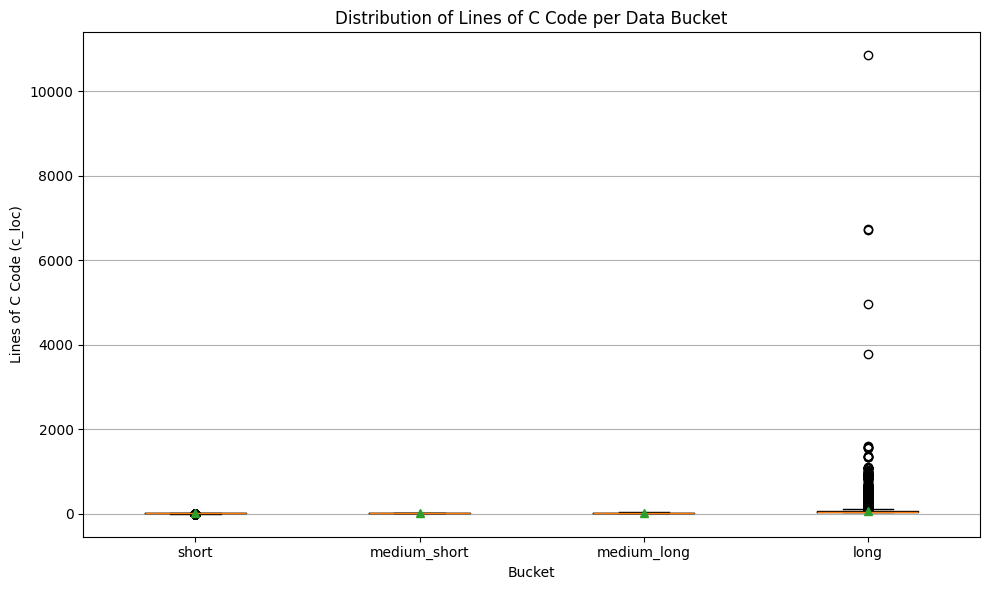

In [1]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
import json

# Load the balanced dataset from the specified path
dataset = load_from_disk("codenet_balanced_hf")

# Extract the 'bucket' and 'c_loc' fields for plotting
bucket_labels = sorted(set(dataset["bucket"]), key=lambda b: dataset["bucket"].index(b))
bucket_to_locs = {bucket: [] for bucket in bucket_labels}

for row in dataset:
    bucket = row["bucket"]
    c_loc = row["c_loc"]
    bucket_to_locs[bucket].append(c_loc)

# Plot the distribution of C LOC for each bucket
plt.figure(figsize=(10, 6))
data = [bucket_to_locs[bucket] for bucket in bucket_labels]
plt.boxplot(data, labels=bucket_labels, showmeans=True)
plt.xlabel("Bucket")
plt.ylabel("Lines of C Code (c_loc)")
plt.title("Distribution of Lines of C Code per Data Bucket")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [2]:
import numpy as np

print("C LOC statistics by bucket:")
for bucket in bucket_labels:
    locs = bucket_to_locs[bucket]
    mean = np.mean(locs)
    median = np.median(locs)
    range_min = np.min(locs)
    range_max = np.max(locs)
    print(f"Bucket {bucket}: mean = {mean:.1f}, median = {median}, range = [{range_min}, {range_max}]")

C LOC statistics by bucket:
Bucket short: mean = 10.7, median = 11.0, range = [1, 15]
Bucket medium_short: mean = 18.4, median = 18.0, range = [16, 21]
Bucket medium_long: mean = 25.6, median = 25.0, range = [22, 30]
Bucket long: mean = 66.0, median = 47.0, range = [31, 10851]


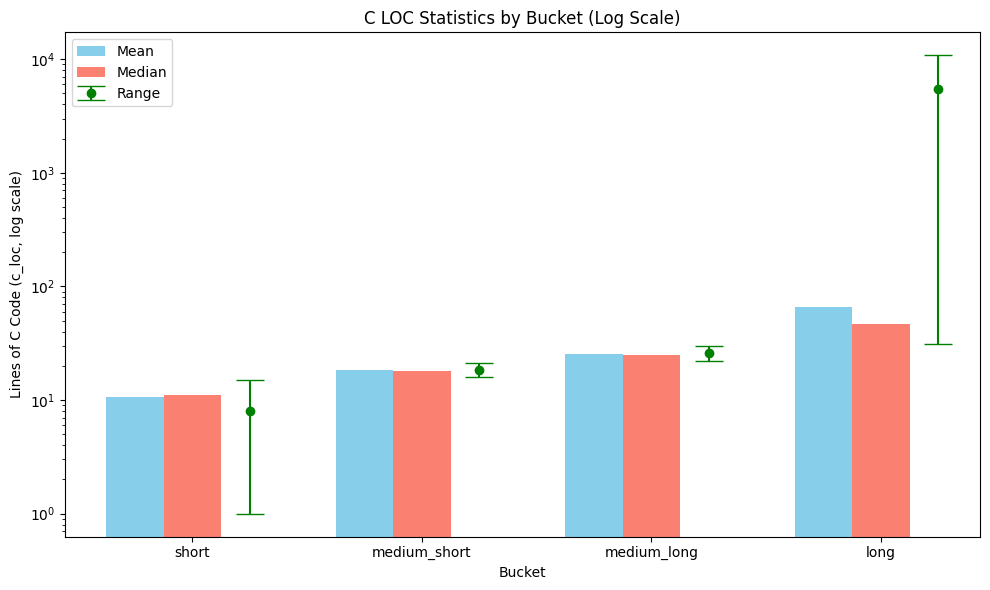

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The `long` bucket has an extreme tail (max ~10k), so min/max range
# is a misleading summary. Use percentiles + a log-scale box plot instead.

percentile_levels = [25, 50, 75, 90, 95, 99]
rows = []
for bucket in bucket_labels:
    locs = np.asarray(bucket_to_locs[bucket])
    row = {
        "bucket": bucket,
        "count": len(locs),
        "mean": locs.mean(),
        "min": locs.min(),
        "max": locs.max(),
    }
    for p, v in zip(percentile_levels, np.percentile(locs, percentile_levels)):
        row[f"p{p}"] = v
    rows.append(row)

summary = pd.DataFrame(rows).set_index("bucket")
print(summary.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: percentile bars on a log scale (clean, interpretable for skewed data)
ax = axes[0]
x = np.arange(len(bucket_labels))
width = 0.13
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(percentile_levels)))
for i, p in enumerate(percentile_levels):
    offset = (i - (len(percentile_levels) - 1) / 2) * width
    ax.bar(x + offset, summary[f"p{p}"].values, width, label=f"p{p}", color=colors[i])
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(bucket_labels)
ax.set_xlabel("Bucket")
ax.set_ylabel("Lines of C Code (log scale)")
ax.set_title("C LOC percentiles by bucket")
ax.legend(ncol=3, fontsize=9)
ax.grid(axis="y", which="both", alpha=0.3)

# Right: log-scale box plot showing the actual distribution + outliers
ax = axes[1]
data = [bucket_to_locs[b] for b in bucket_labels]
bp = ax.boxplot(
    data,
    tick_labels=bucket_labels,
    showmeans=True,
    meanline=True,
    patch_artist=True,
    flierprops=dict(marker=".", markersize=3, alpha=0.3),
)
for patch in bp["boxes"]:
    patch.set_facecolor("#cfe2ff")
    patch.set_edgecolor("#1f4e8a")
ax.set_yscale("log")
ax.set_xlabel("Bucket")
ax.set_ylabel("Lines of C Code (log scale)")
ax.set_title("C LOC distribution by bucket (log scale)")
ax.grid(axis="y", which="both", alpha=0.3)

plt.tight_layout()
plt.show()